In [1]:
from pathlib import Path

from cr_knee_fit.analysis import FitConfig
from cr_knee_fit.fit_data import Data
from cr_knee_fit.model import Model

In [2]:
from cr_knee_fit.inference import GoodnessOfFit


def load_mle_model(outdir: Path | str) -> tuple[FitConfig, Model, GoodnessOfFit]:
    outdir = Path(outdir)
    config_path = outdir / "config-dump.json"
    config = FitConfig.model_validate_json(config_path.read_text())
    m = Model.load(outdir / "mle-prelim.txt", layout_info=config.model)
    assert m is not None, "MLE model not found"
    return (config, m, GoodnessOfFit.load(outdir / "mle-prelim.gof.json"))

In [3]:
import numpy as np
from scipy import stats


def get_significance(twopop_dir: str, verbose: bool = False):
    log = print if verbose else lambda x: None
    *_, two_res = load_mle_model(twopop_dir)
    *_, three_res = load_mle_model(twopop_dir.replace("2pop", "3pop"))

    log(f"2pop: {two_res}, AIC p = {np.exp(0.5 * (three_res.aic - two_res.aic))}")
    log(f"3pop: {three_res}")

    TS = 2 * (three_res.logpost - two_res.logpost)
    ndof = two_res.ndof - three_res.ndof
    log(f"TS = {TS:.4g}, approximately following chi2 with ndof = {ndof}")
    p = 1 - stats.chi2.cdf(TS, ndof)
    log(f"pvalue = {p:.4g}")

    sigma = stats.norm.ppf(1 - p / 2)
    log(f"-> {sigma:.4g} sigma significance")

    return sigma

# Third population significance in the fiducial model

In [4]:
hims = ("sibyll", "epos", "qgsjet")
for him in hims:
    print()
    print(him)
    get_significance(f"../out/3pop_significance/2pop/lhaaso_{him}/lambda=1.0", verbose=True)


sibyll
2pop: logpost = -246.441; D / ndof = 514 / 827 = 0.6216; AIC = 554.882, AIC p = 0.030736612801211798
3pop: logpost = -237.959; D / ndof = 497.1 / 822 = 0.6047; AIC = 547.917
TS = 16.96, approximately following chi2 with ndof = 5
pvalue = 0.004567
-> 2.836 sigma significance

epos
2pop: logpost = -252.261; D / ndof = 525.7 / 827 = 0.6356; AIC = 566.522, AIC p = 0.478873368152799
3pop: logpost = -246.525; D / ndof = 514.2 / 822 = 0.6255; AIC = 565.049
TS = 11.47, approximately following chi2 with ndof = 5
pvalue = 0.04277
-> 2.026 sigma significance

qgsjet
2pop: logpost = -249.708; D / ndof = 520.6 / 827 = 0.6295; AIC = 561.416, AIC p = 0.0018439593881178964
3pop: logpost = -238.412; D / ndof = 498 / 822 = 0.6058; AIC = 548.824
TS = 22.59, approximately following chi2 with ndof = 5
pvalue = 0.000404
-> 3.537 sigma significance


# Logposterior value of the fixed model vs. $\lambda_\text{syst}$

In [5]:
from cr_knee_fit.fit_data import GenericExperimentData
from cr_knee_fit.inference import set_default_chi2_method, set_default_lognormal_chi2


def compute_gofs_vs_lambda_grid(
    lambda_syst_grid: np.ndarray,
    model_dir: str | Path,
) -> tuple[GoodnessOfFit, list[GoodnessOfFit]]:
    set_default_lognormal_chi2(True)

    config, m, _ = load_mle_model(model_dir)

    set_default_chi2_method("dimidated")
    fit_data = Data.load(config.fit_data_config)
    gof_uncorr = GoodnessOfFit.compute(m, fit_data)

    set_default_chi2_method("correlated")

    gofs: list[GoodnessOfFit] = []
    for lambda_syst in lambda_syst_grid:
        GenericExperimentData.default_systematics_correlation_length = lambda_syst
        # HACK: we load the data anew every time, so inv_err_cov is not cached but rather re-computed every time
        fit_data = Data.load(config.fit_data_config)
        gofs.append(GoodnessOfFit.compute(m, fit_data))

    return gof_uncorr, gofs

In [6]:
def compute_sigma_significance(gof1: GoodnessOfFit, gof2: GoodnessOfFit) -> float:
    TS = 2 * (gof2.logpost - gof1.logpost)
    ndof = gof1.ndof - gof2.ndof
    p = 1 - stats.chi2.cdf(TS, ndof)
    return float(stats.norm.ppf(1 - p / 2))

In [16]:
def compute_sigma_vs_lambda_syst(him: str) -> tuple[list[float], list[float]]:
    print(him)
    lambda_syst_grid = np.linspace(0.1, 3, 100)
    gof_uncorr_1, gofs1 = compute_gofs_vs_lambda_grid(
        lambda_syst_grid, f"../out/3pop_significance/2pop/lhaaso_{him}/lambda=1.0"
    )
    gof_uncorr_2, gofs2 = compute_gofs_vs_lambda_grid(
        lambda_syst_grid, f"../out/3pop_significance/3pop/lhaaso_{him}/lambda=1.0"
    )

    sigma_uncorr = compute_sigma_significance(gof_uncorr_1, gof_uncorr_2)
    print(sigma_uncorr)
    sigmas = [compute_sigma_significance(gof1, gof2) for gof1, gof2 in zip(gofs1, gofs2)]

    return [0.0, *lambda_syst_grid], [sigma_uncorr, *sigmas]

In [17]:
res_by_him = {him: compute_sigma_vs_lambda_syst(him) for him in hims}

sibyll


/home/nj-vs-vh/Documents/Science/cr-knee-fit/cr_knee_fit/crams_model.py:543: RuntimeWarning: divide by zero encountered in log10
  return np.log10(self.crams.compute(self.propagation, self.injection))


6.083046455216993
epos
6.24120246114468
qgsjet
inf


In [19]:
him_label = {
    "sibyll": "Sibyll 2.3d",
    "epos": "EPOS.LHC",
    "qgsjet": "QGSJetII-04",
}
him_color = {
    "sibyll": "#E58606",
    "epos": "#5D69B1",
    "qgsjet": "#52BCA3",
}

Text(0, 0.5, 'Third population significance / $\\sigma$')

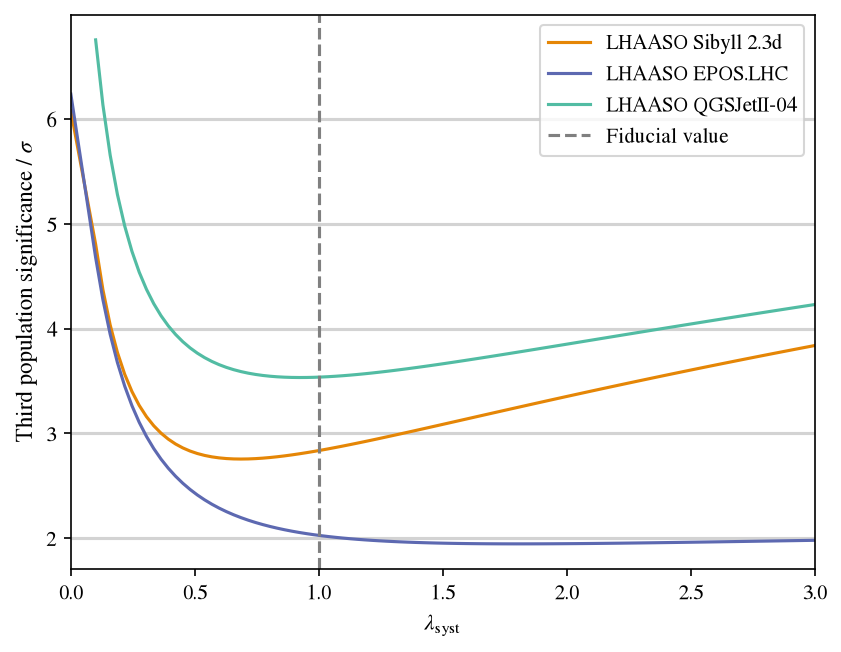

In [23]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

for him, res in res_by_him.items():
    ax.plot(*res, label="LHAASO " + him_label[him], color=him_color[him])
ax.axvline(1.0, color="gray", ls="--", label="Fiducial value")
for sigmas in (2, 3, 4, 5, 6):
    ax.axhline(sigmas, color="lightgray", ls="-", zorder=-10)

ax.set_xlabel("$\\lambda_\\text{syst}$")
ax.set_xlim(0, 3)
ax.legend()
ax.set_ylabel("Third population significance / $\\sigma$")